In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scanpy.external as sce
from scipy.stats import spearmanr
import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
from scib_metrics.benchmark import Benchmarker
from scib_metrics.benchmark import BioConservation, BatchCorrection

from plottable import Table, ColumnDefinition
from plottable.cmap import normed_cmap
import matplotlib as mpl

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

In [2]:
import scib_metrics
print(scib_metrics.__version__)

0.5.9


# Load data

In [3]:
%%time
# h5ad built in Hematokytos/figure3/timeseries_embedding.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/scfib_hsc_parse_integration_wFA.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 314 ms, sys: 2.51 s, total: 2.82 s
Wall time: 8.42 s


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_

In [4]:
display(adata.obs['batch'].value_counts())
display(adata.obs['group_label'].value_counts())

batch
hsc      8357
fib      6960
parse    6174
Name: count, dtype: int64

group_label
Control     7842
R2          4343
R1          1982
D14         1973
D7          1529
spike-in    1508
D21         1331
R3           524
D0           459
Name: count, dtype: int64

# Batch correction

In [5]:
adata.obs["non_reprogrammed"] = False

fib_control_mask = (
    (adata.obs["batch"] == "fib") # 6960
    |
    ((adata.obs["batch"] == "parse") & (adata.obs["group_label"].isin(["Control", "D0"]))) # 882 + 459
    |
    ((adata.obs["batch"] == "hsc") & (adata.obs["group_label"] == 'spike-in')) # 1508
)

adata.obs.loc[fib_control_mask, "non_reprogrammed"] = True

display(adata.obs['non_reprogrammed'].value_counts())

pd.crosstab(
    adata.obs['non_reprogrammed'],
    adata.obs['batch']
)

non_reprogrammed
False    11682
True      9809
Name: count, dtype: int64

batch,fib,hsc,parse
non_reprogrammed,,,
False,0,6849,4833
True,6960,1508,1341


In [7]:
%%time

# created shared 'non-reprogrammed' label across batches -- contains scFib + parse Control/D0 + spike-ins
adata_nr = adata[adata.obs['non_reprogrammed'].astype(bool)].copy()
adata_nr

adata_nr.obs["anchor_label"] = "non_reprogrammed"
adata_nr.obs["anchor_label"] = adata_nr.obs["anchor_label"].astype("category")
adata_nr.obs["batch"] = adata_nr.obs["batch"].astype("category")

embedding_keys = [
    "X_pca_unintegrated",
    "X_harmony_batch_only",
    "X_harmony_regress_cc",
    "X_scvi_batch_only",
    "X_scANVI_batch_only",
    "X_scvi_cc_covar",
    "X_scANVI_cc_covar",
]

bm_nr = Benchmarker(
    adata_nr,
    batch_key='batch',
    label_key='anchor_label',
    embedding_obsm_keys=embedding_keys,
    pre_integrated_embedding_obsm_key="X_pca_unintegrated",
    bio_conservation_metrics=None,
    batch_correction_metrics=BatchCorrection(
        bras=True,
        ilisi_knn=True,
        kbet_per_label=True,
        graph_connectivity=False,
        pcr_comparison=True
    ),
    n_jobs=-1
)

bm_nr.benchmark()

Metrics:   0%|          | 0/5 [00:00<?, ?it/s, Batch correction: bras]INFO:2026-06-22 13:08:24,819:jax._src.xla_bridge:924: Unable to initialize backend 'cuda': 
2026-06-22 13:08:24 | [INFO] Unable to initialize backend 'cuda': 
INFO:2026-06-22 13:08:24,821:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-06-22 13:08:24 | [INFO] Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-06-22 13:08:24,841:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-22 13:08:24 | [INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-22 13:08:24 | [WARNING] An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not in

CPU times: user 2min 24s, sys: 7.49 s, total: 2min 31s
Wall time: 2min 34s


,BRAS,iLISI,KBET,PCR comparison,Batch correction
Embedding,,,,,
X_pca_unintegrated,0.466835,0.0,0.0,0.0,0.116709
X_harmony_batch_only,0.761744,0.001977,0.007646,0.621497,0.348216
X_harmony_regress_cc,0.790575,0.011593,0.008564,0.643819,0.363637
X_scvi_batch_only,0.829576,0.022079,0.008564,0.766994,0.406803
X_scANVI_batch_only,0.837044,0.061874,0.028953,0.822986,0.437714
X_scvi_cc_covar,0.796411,0.020753,0.010704,0.68474,0.378152
X_scANVI_cc_covar,0.82728,0.060213,0.024161,0.76958,0.420309
Metric Type,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score


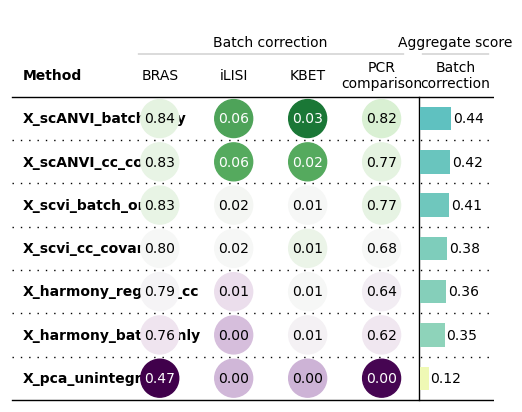

In [9]:
nr_results = bm_nr.get_results(min_max_scale=False)
display(nr_results)

bm_nr.plot_results_table()

# Bio conservation

In [10]:
# Use one dataset with known state labels (e.g., parse)
adata_parse = adata[adata.obs['batch'] == 'parse'].copy()
                    
                    
condition_map = {
    'Control_1_1': 'Control',
    'Control_1_2': 'Control',
    'Control_2_TD': 'Control',
    'D7': 'D7',
    'D14': 'D14',
    'D21': 'D21',
}

adata_parse.obs["condition_group"] = (
    adata_parse.obs["condition"].map(condition_map)
)
adata_parse.obs["condition_group"] = adata_parse.obs["condition_group"].astype("category")
adata_parse.obs["condition_group"].value_counts(sort=False)

embedding_keys = [
    "X_pca_unintegrated",
    "X_harmony_batch_only",
    "X_harmony_regress_cc",
    "X_scvi_batch_only",
    "X_scANVI_batch_only",
    "X_scvi_cc_covar",
    "X_scANVI_cc_covar",
]

bm_p = Benchmarker(
    adata_parse,
    batch_key='batch',
    label_key='condition_group',
    embedding_obsm_keys=embedding_keys,
    pre_integrated_embedding_obsm_key="X_pca_unintegrated",
    bio_conservation_metrics=BioConservation(
        isolated_labels=True,
        nmi_ari_cluster_labels_kmeans=True,
        nmi_ari_cluster_labels_leiden=True,
        silhouette_label=True,
        clisi_knn=True
    ),   
    batch_correction_metrics=None,
    n_jobs=-1
)

bm_p.benchmark()

Metrics:   0%|          | 0/5 [00:00<?, ?it/s, Bio conservation: isolated_labels]2026-06-22 13:10:47 | [INFO] isolated labels: no more than 1 batches per label

Embeddings:  14%|█▍        | 1/7 [00:26<02:41, 26.88s/it]o conservation: clisi_knn]
                                                                                   
Metrics:   0%|          | 0/5 [00:00<?, ?it/s, Bio conservation: isolated_labels]2026-06-22 13:11:14 | [INFO] isolated labels: no more than 1 batches per label

Embeddings:  29%|██▊       | 2/7 [00:51<02:07, 25.47s/it]o conservation: clisi_knn]
                                                                                   
Metrics:   0%|          | 0/5 [00:00<?, ?it/s, Bio conservation: isolated_labels]2026-06-22 13:11:38 | [INFO] isolated labels: no more than 1 batches per label

Embeddings:  43%|████▎     | 3/7 [01:16<01:40, 25.13s/it]o conservation: clisi_knn]
                                                                                   
Metrics:   0%

,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,Bio conservation
Embedding,,,,,,,,
X_pca_unintegrated,0.53389,0.652048,0.618789,0.577635,0.571735,0.540767,0.972525,0.638198
X_harmony_batch_only,0.523296,0.595759,0.580202,0.501469,0.490135,0.52949,0.9425,0.594693
X_harmony_regress_cc,0.5239,0.634169,0.608163,0.54554,0.546909,0.529142,0.940074,0.618271
X_scvi_batch_only,0.565219,0.760006,0.675048,0.602681,0.60383,0.570885,0.983513,0.680169
X_scANVI_batch_only,0.574454,0.776842,0.693051,0.673516,0.599753,0.580939,0.991197,0.698536
X_scvi_cc_covar,0.566903,0.766748,0.681985,0.604391,0.596016,0.570647,0.979314,0.680858
X_scANVI_cc_covar,0.576359,0.762262,0.687623,0.604533,0.606743,0.580502,0.985737,0.686251
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Aggregate score


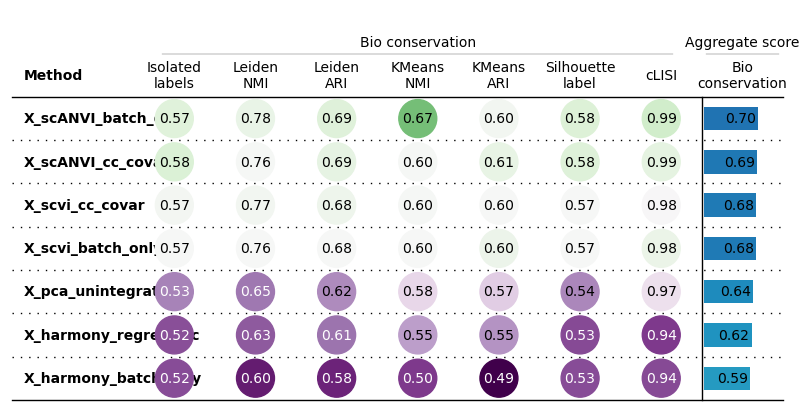

In [11]:
p_results = bm_p.get_results(min_max_scale=False)
display(p_results)

bm_p.plot_results_table()

# Pretty plots

In [23]:
def fixed_cmap(cmap, vmin=0, vmax=1, na_color="white"):
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    def _mapper(val):
        if pd.isna(val):
            return na_color
        return cmap(norm(val))

    return _mapper

def plot_custom_scib_results_table(
    benchmarker,
    method_label_map=None,
    metric_label_map=None,
    method_order=None,
    sort_col=None,
    benchmark_label='Bio conservation',
    figsize=(13, 4.5),
    dpi=100,
    title="scIB-metrics Benchmark Results",
    save_path=None,
    min_max_scale=True,
):
    """
    Custom plottable-based version of scib-metrics plot_results_table().
    """

    method_label_map = method_label_map or {}
    metric_label_map = metric_label_map or {}

    results = benchmarker.get_results(min_max_scale=min_max_scale)

    metric_types = None
    if "Metric Type" in results.index:
        metric_types = results.loc["Metric Type"].to_dict()

    results_numeric = (
        results
        .drop(index="Metric Type", errors="ignore")
        .apply(pd.to_numeric, errors="coerce")
    )

    # Rename methods
    results_numeric = results_numeric.rename(index=method_label_map)
    
    if sort_col is not None:
        results_numeric = results_numeric.sort_values(by=sort_col, ascending=False)
    
    # Reorder methods
    if method_order is not None:
        results_numeric = results_numeric.loc[
            [x for x in method_order if x in results_numeric.index]
        ]

    # Move index into a column
    plot_df = results_numeric.copy()
    plot_df.insert(0, "Method", plot_df.index)
    plot_df = plot_df.reset_index(drop=True)
    
    column_definitions = [
        ColumnDefinition(
            name="Method",
            title="Method",
            width=1.9,
            textprops={
                "ha": "left",
                "weight": "bold",
                "fontsize": 10,
            },
        )
    ]

    
    for col in results_numeric.columns:
        display_title = metric_label_map.get(col, col)

        group = ""
        if metric_types is not None:
            group = metric_types.get(col, "")
        
        
        is_bio_metric = (
            metric_types is not None
            and metric_types.get(col) == benchmark_label
            and col != benchmark_label # exclude aggregate column
        )
        
        if is_bio_metric:
            column_definitions.append(
                ColumnDefinition(
                    name=col,
                    title=display_title,
                    group=group,
                    width=0.85,
                    textprops={
                        "ha": "center",
                        "va": "center",
                        "fontsize": 10,
                        "weight": "normal",
                        "bbox": {
                            "boxstyle": "circle",#,pad=0.35",
                            "pad": 0.2,
                            "edgecolor": "white",#"#4C78A8",
                            "linewidth": 0.8,
                        },
                    },
                    formatter="{:.2f}",
                    cmap=normed_cmap(plot_df[col], cmap=mpl.cm.PiYG, num_stds=2)#bio_circle_cmap
                )
            )

        elif col in ["Total", "Bio conservation", "Batch correction"]:
            cmap = normed_cmap(
                plot_df[col],
                cmap=mpl.cm.Blues,
                num_stds=2.5,
            )

            column_definitions.append(
                ColumnDefinition(
                    name=col,
                    title=display_title,
                    group=group,
                    width=1.05,
                    textprops={
                        "ha": "center",
                        "fontsize": 10,
                        "weight": "bold",
                    },
                    formatter="{:.2f}",
                    cmap=cmap,
                )
            )

        else:
            cmap = normed_cmap(
                plot_df[col],
                cmap=mpl.cm.YlGnBu,
                num_stds=2.5,
            )

            column_definitions.append(
                ColumnDefinition(
                    name=col,
                    title=display_title,
                    group=group,
                    width=0.85,
                    textprops={
                        "ha": "center",
                        "fontsize": 9,
                        "weight": "normal",
                    },
                    formatter="{:.2f}",
                    cmap=cmap,
                )
            )
            
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    table = Table(
        plot_df,
        column_definitions=column_definitions,
        ax=ax,
        row_dividers=True,
        footer_divider=True,
        textprops={
            "fontsize": 10,
            "fontfamily": "DejaVu Sans",
        },
        row_divider_kw={
            "linewidth": 1.5,
            "linestyle": ":",
            "color": "black",
        },
        col_label_divider_kw={
            "linewidth": 1.5,
            "linestyle": "-",
            "color": "black",
        },
        column_border_kw={
            "linewidth": 1.5,
            "linestyle": "-",
            "color": "0.85",
        },
    ).autoset_fontcolors()

    ax.set_title(
        title,
        fontsize=15,
        weight="bold",
        pad=10,
    )

    plt.tight_layout()
    # fig.show()

    return fig, ax, table

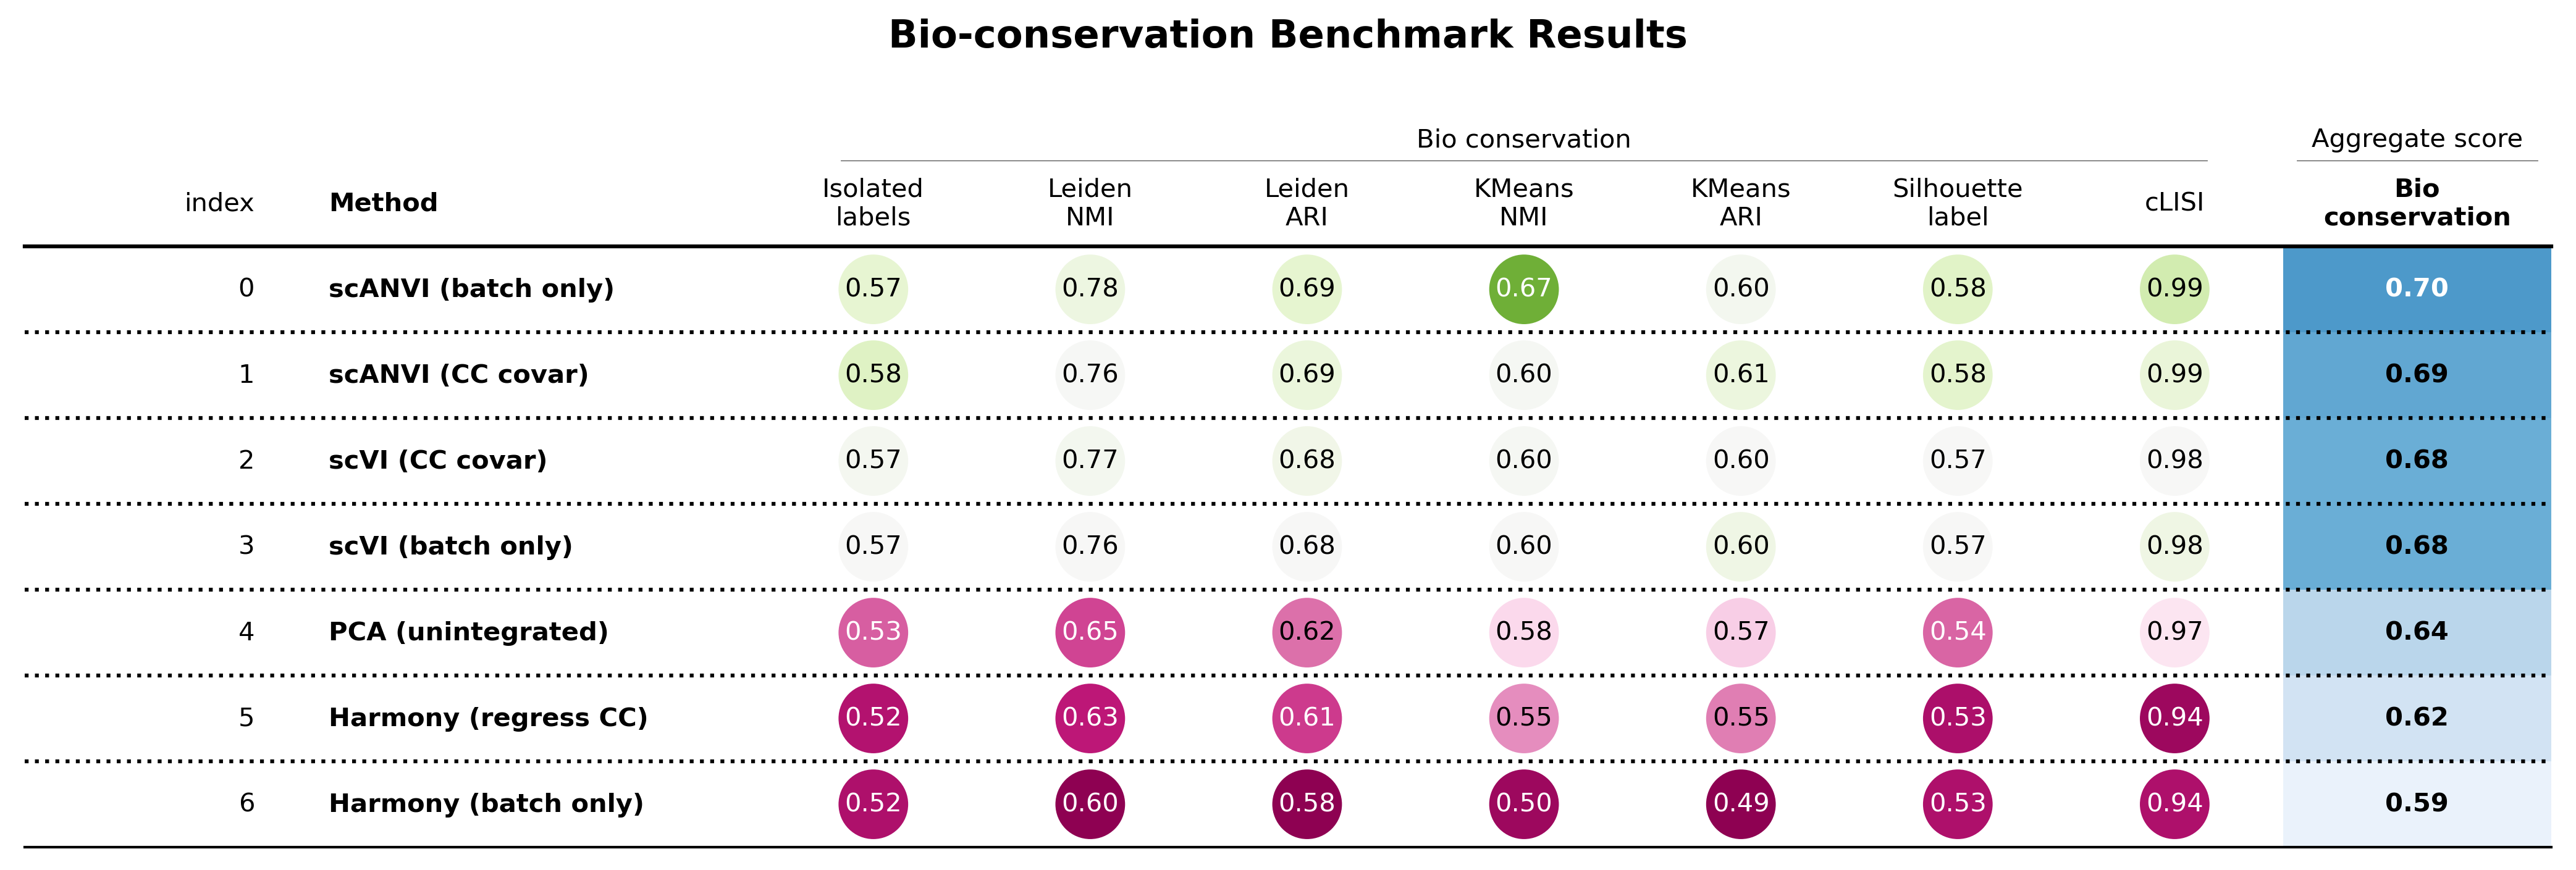

In [29]:
method_label_map = {
    "X_pca_unintegrated": "PCA (unintegrated)",
    "X_harmony_batch_only": "Harmony (batch only)",
    "X_harmony_regress_cc": "Harmony (regress CC)",
    "X_scvi_batch_only": "scVI (batch only)",
    "X_scANVI_batch_only": "scANVI (batch only)",
    "X_scvi_cc_covar": "scVI (CC covar)",
    "X_scANVI_cc_covar": "scANVI (CC covar)",
}

metric_label_map = {
    "Isolated labels": "Isolated\nlabels",
    "KMeans NMI": "KMeans\nNMI",
    "KMeans ARI": "KMeans\nARI",
    "Leiden NMI": "Leiden\nNMI",
    "Leiden ARI": "Leiden\nARI",
    "Silhouette label": "Silhouette\nlabel",
    "cLISI": "cLISI",
    "Bio conservation": "Bio\nconservation",
    "Batch correction": "Batch\ncorrection",
    "Total": "Total",
}

fig, ax, table = plot_custom_scib_results_table(
    bm_p,
    method_label_map=method_label_map,
    metric_label_map=metric_label_map,
    sort_col='Bio conservation',
    figsize=(14, 4.8),
    title="Bio-conservation Benchmark Results",
    min_max_scale=False,
    dpi=300,
)

plt.show()

In [ ]:
# scANVI was evaluated alongside unsupervised methods, but because it uses label information during training, 
# biological conservation metrics involving related labels should be interpreted as 
# semi-supervised performance rather than a purely unsupervised integration benchmark.

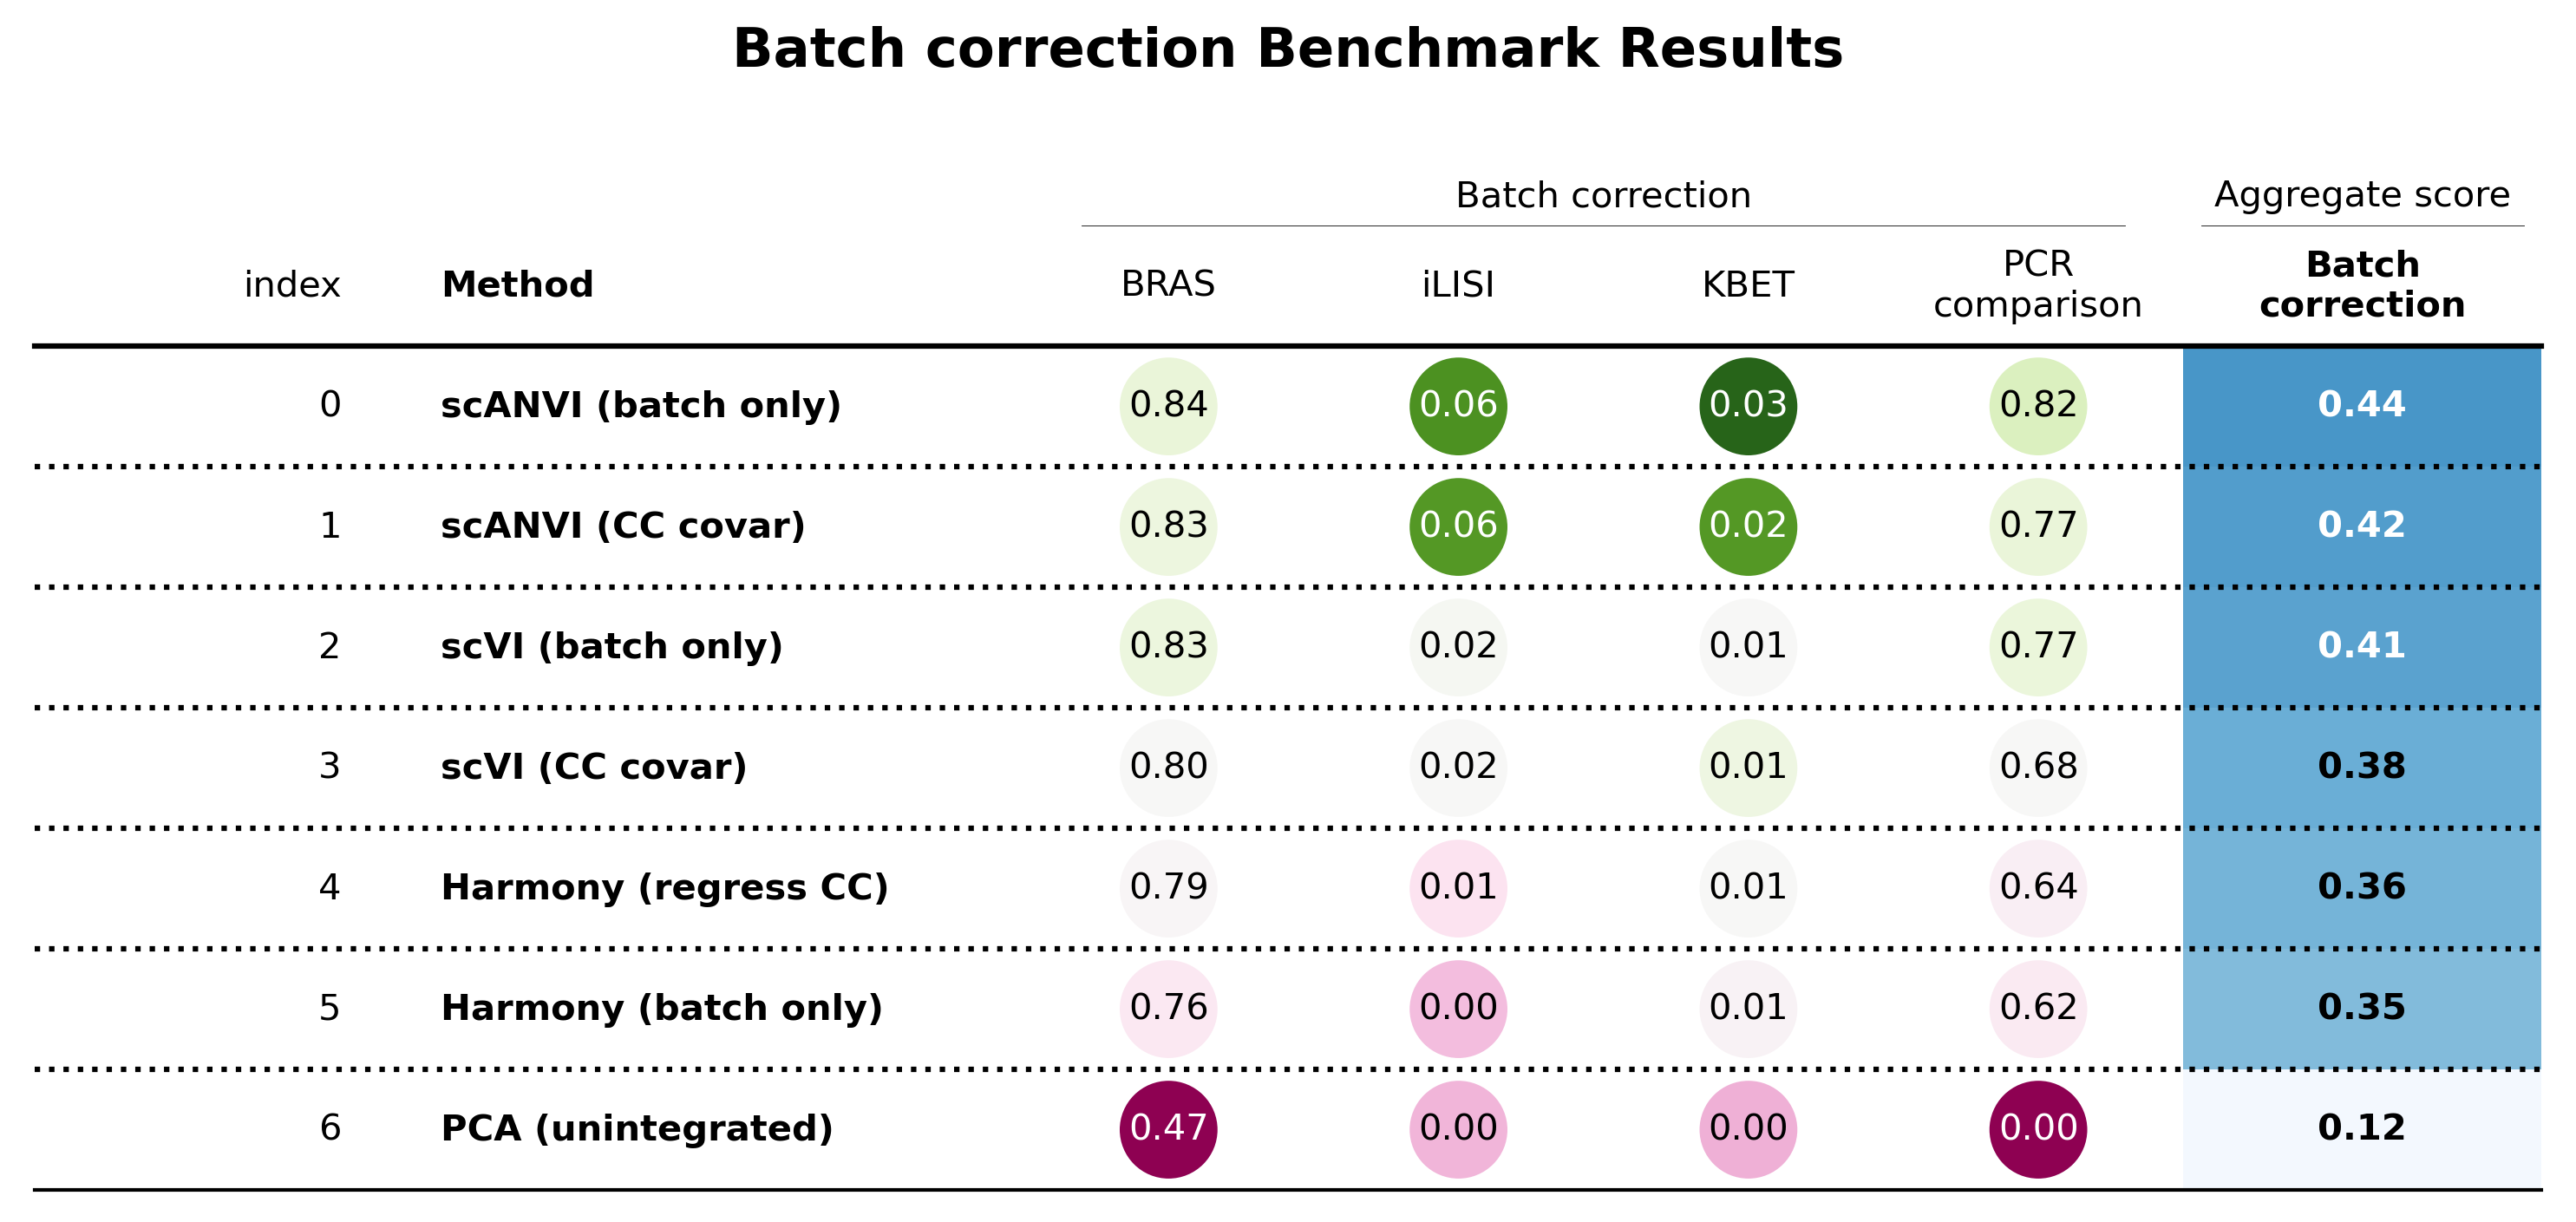

In [30]:
metric_label_map = {
    "BRAS": "BRAS",
    "iLISI": "iLISI",
    "KBET": "KBET",
    "PCR comparison": "PCR\ncomparison",
    "Batch correction": "Batch\ncorrection",
    "Total": "Total",
}

fig, ax, table = plot_custom_scib_results_table(
    bm_nr,
    method_label_map=method_label_map,
    metric_label_map=metric_label_map,
    benchmark_label='Batch correction',
    sort_col='Batch correction',
    figsize=(10, 4.8),
    title="Batch correction Benchmark Results",
    min_max_scale=False,
    dpi=300,
)

plt.show()

# Cell cycle compare

In [8]:
%%time
adata_eval = adata.copy()

def latent_cell_cycle_correlations(adata, rep, s_key="S_score", g2m_key="G2M_score"):
    X = adata.obsm[rep]
    rows = []

    for i in range(X.shape[1]):
        s_corr = spearmanr(X[:, i], adata.obs[s_key]).correlation
        g_corr = spearmanr(X[:, i], adata.obs[g2m_key]).correlation

        rows.append({
            "representation": rep,
            "dim": i,
            "S_score_spearman": s_corr,
            "G2M_score_spearman": g_corr,
            "max_abs_cc_corr": max(abs(s_corr), abs(g_corr)),
        })

    return pd.DataFrame(rows)


embedding_keys = [
    "X_pca_unintegrated",
    "X_harmony_batch_only",
    "X_harmony_regress_cc",
    "X_scvi_batch_only",
    "X_scANVI_batch_only",
    "X_scvi_cc_covar",
    "X_scANVI_cc_covar",
]

cc_corrs = pd.concat(
    [
        latent_cell_cycle_correlations(adata_eval, rep)
        for rep in embedding_keys
    ],
    ignore_index=True
)

cc_summary = (
    cc_corrs
    .groupby("representation")["max_abs_cc_corr"]
    .agg(["mean", "median", "max"])
    .sort_values("median")
)

cc_summary

CPU times: user 2.9 s, sys: 1.15 s, total: 4.04 s
Wall time: 4.08 s


,mean,median,max
representation,,,
X_pca_unintegrated,0.068927,0.030658,0.541842
X_harmony_regress_cc,0.059515,0.045383,0.258018
X_harmony_batch_only,0.104749,0.063064,0.597681
X_scvi_cc_covar,0.078171,0.073255,0.202193
X_scANVI_cc_covar,0.108070,0.100282,0.218361
X_scvi_batch_only,0.152921,0.113337,0.643401
X_scANVI_batch_only,0.180956,0.116098,0.654420


# Embedding compare

In [9]:
adata_eval = adata.copy()

adata_eval

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_

In [10]:
adata_eval.obs['batch'].value_counts()

batch
hsc      8357
fib      6960
parse    6174
Name: count, dtype: int64

In [11]:
adata_eval.obs['group_label'] = adata_eval.obs['group_label'].cat.add_categories(['scFib'])

adata_eval.obs.loc[adata_eval.obs['batch'] == 'fib', 'group_label'] = 'scFib'

In [12]:
adata_eval.uns['batch_colors'] = ['Grey', 'deepskyblue', '#FECD6F']
adata_eval.uns['phase_colors'] = ['#ad3803', '#56b567', 'gold']

## UMAP

X_pca_unintegrated:


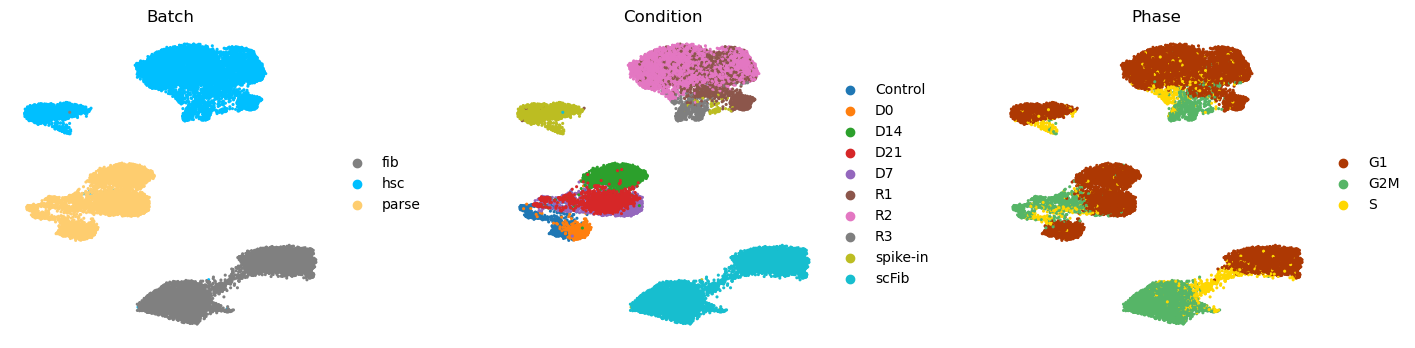

X_harmony_batch_only:


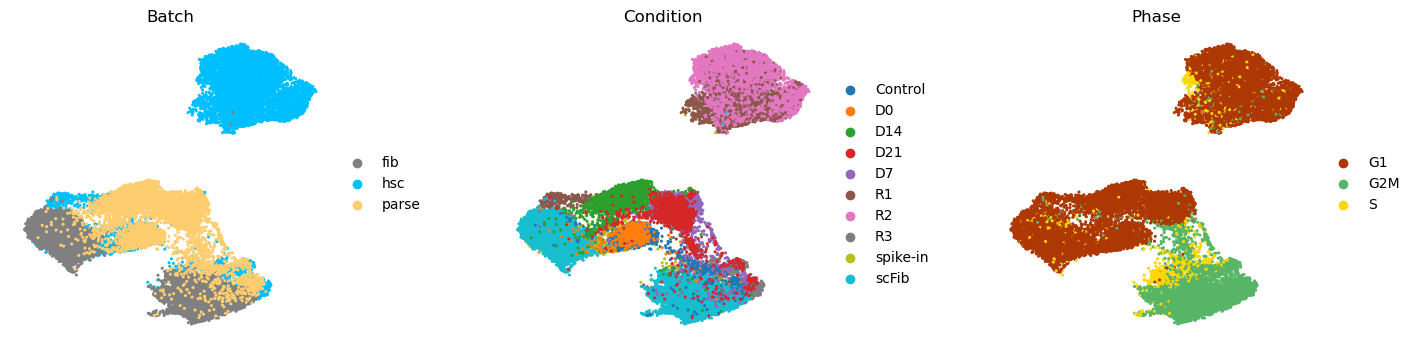

X_harmony_regress_cc:


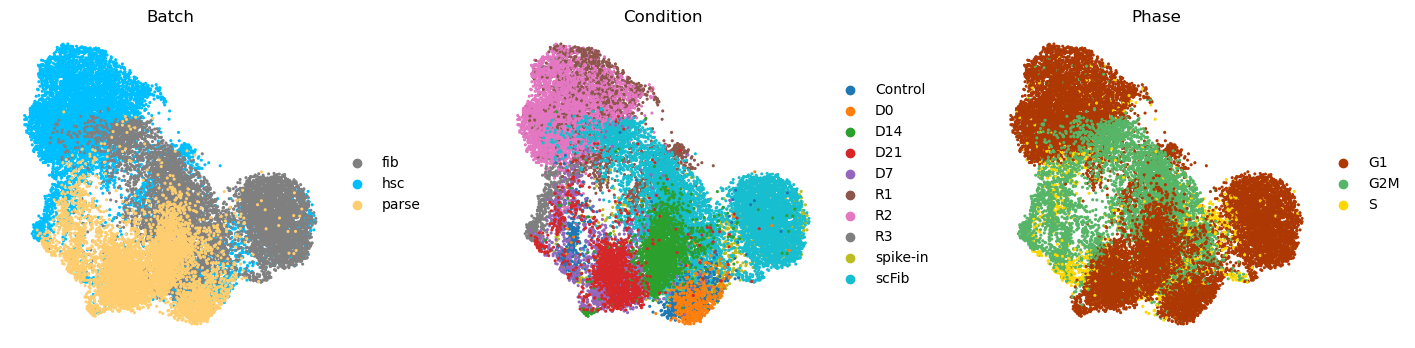

X_scvi_batch_only:


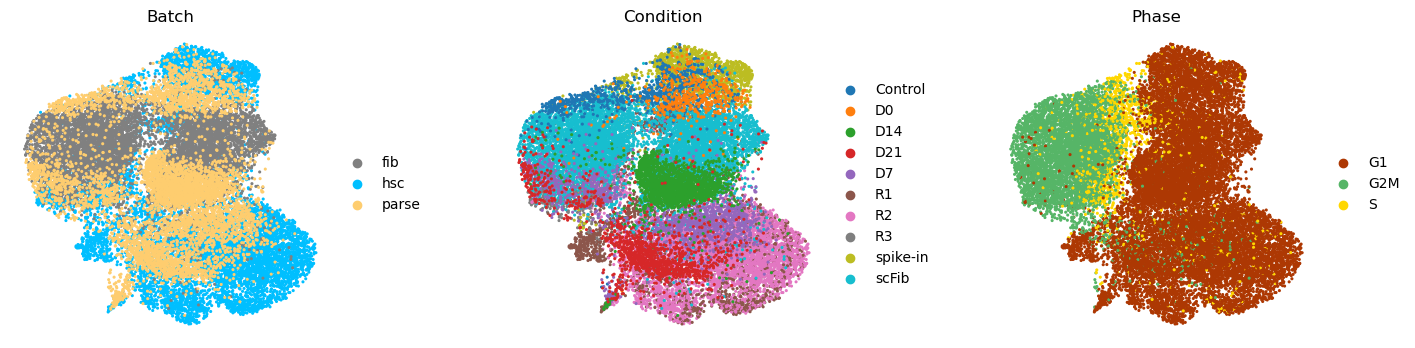

X_scANVI_batch_only:


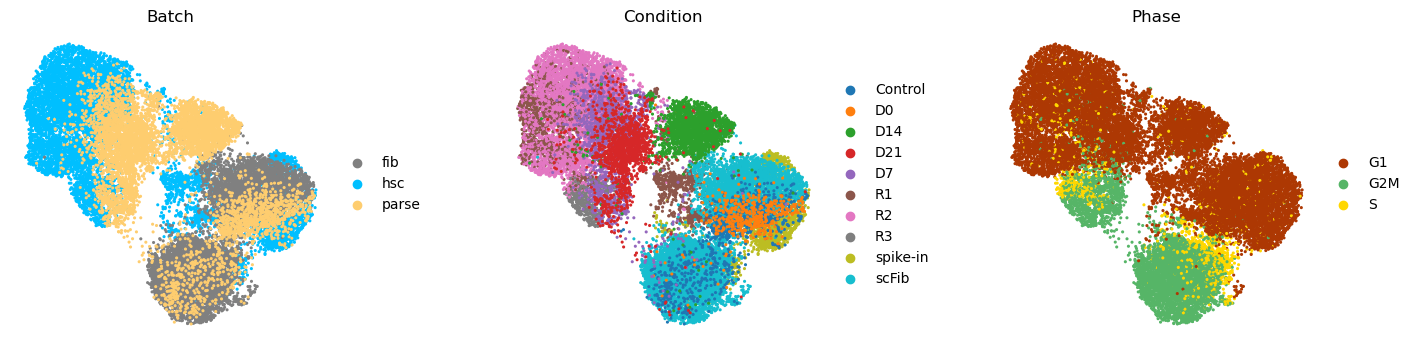

X_scvi_cc_covar:


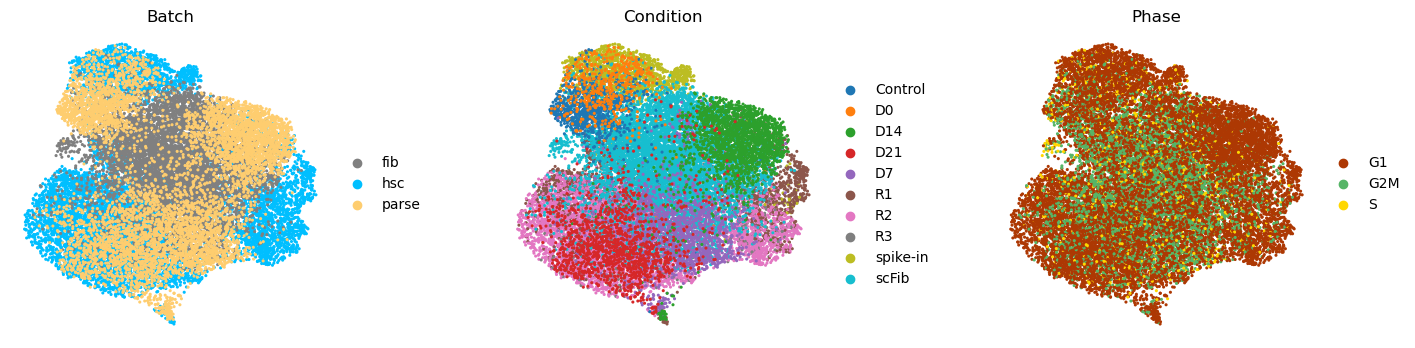

X_scANVI_cc_covar:


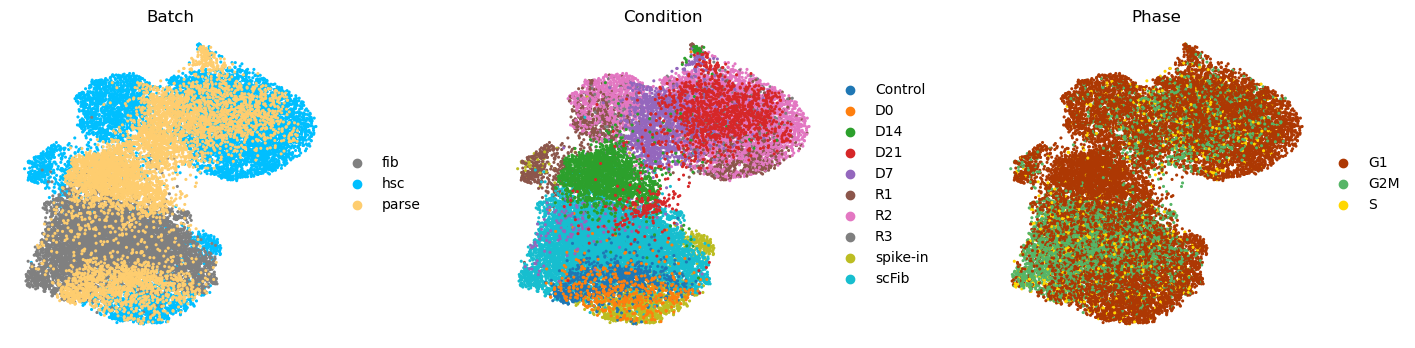

CPU times: user 8.04 s, sys: 3.25 s, total: 11.3 s
Wall time: 12.5 s


In [13]:
%%time
n_neighbors = 35

embedding_keys = [
    "X_pca_unintegrated",
    "X_harmony_batch_only",
    "X_harmony_regress_cc",
    "X_scvi_batch_only",
    "X_scANVI_batch_only",
    "X_scvi_cc_covar",
    "X_scANVI_cc_covar",
]

for rep in embedding_keys:
    
    rsc.get.anndata_to_GPU(adata_eval)
    
    rsc.pp.neighbors(adata_eval, use_rep=rep, n_neighbors=n_neighbors)
    rsc.tl.umap(adata_eval)
    
    rsc.get.anndata_to_CPU(adata_eval)

    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['figure.figsize'] = 4, 4
    
    print(f'{rep}:')
    
    sc.pl.umap(
        adata_eval,
        ncols=3,
        size=20,
        color=['batch', 'group_label', "phase"],
        title=[
            f"Batch",
            f"Condition",
            f"Phase",
        ],
        frameon=False,
        wspace=0.4,
    )

## FA

X_pca_unintegrated:


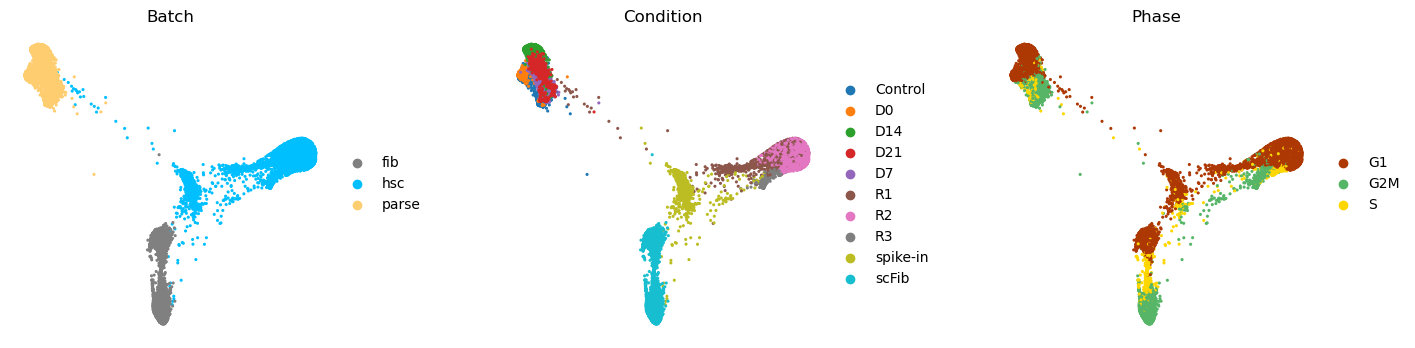

X_harmony_batch_only:


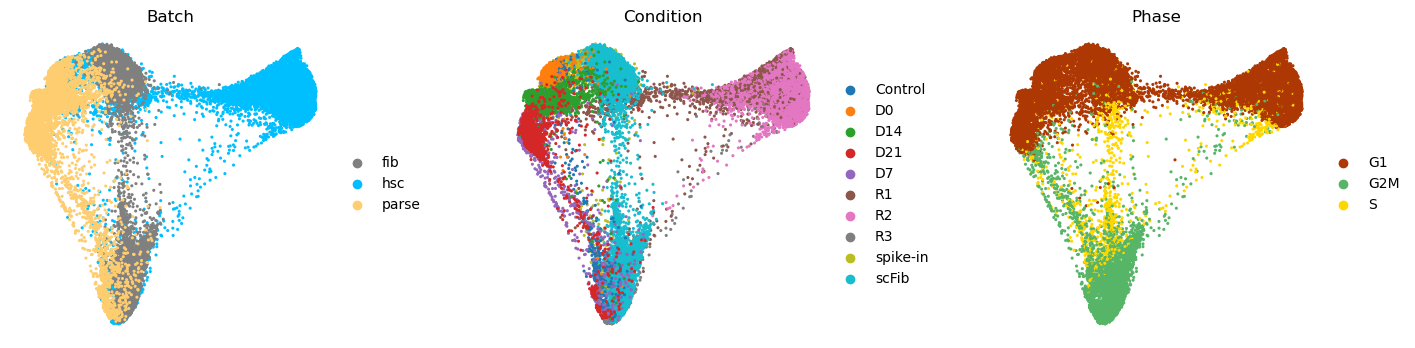

X_harmony_regress_cc:


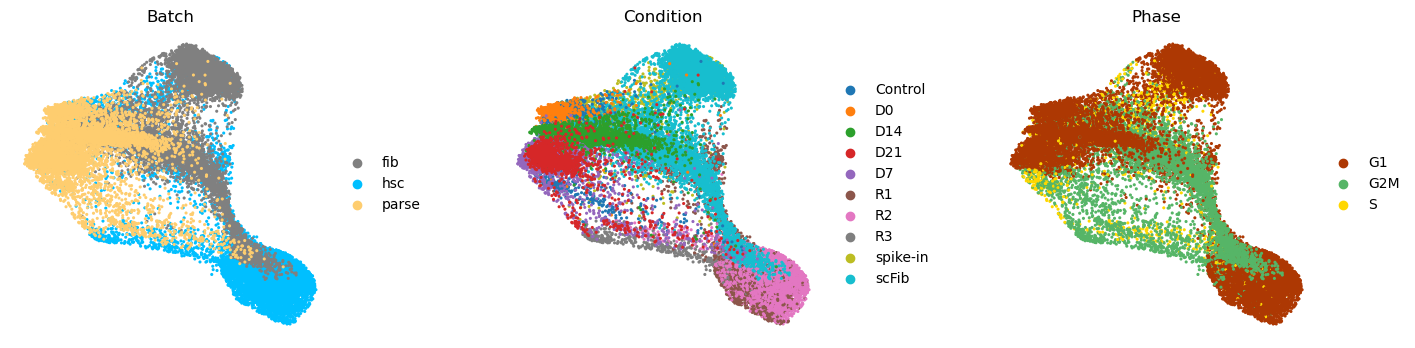

X_scvi_batch_only:


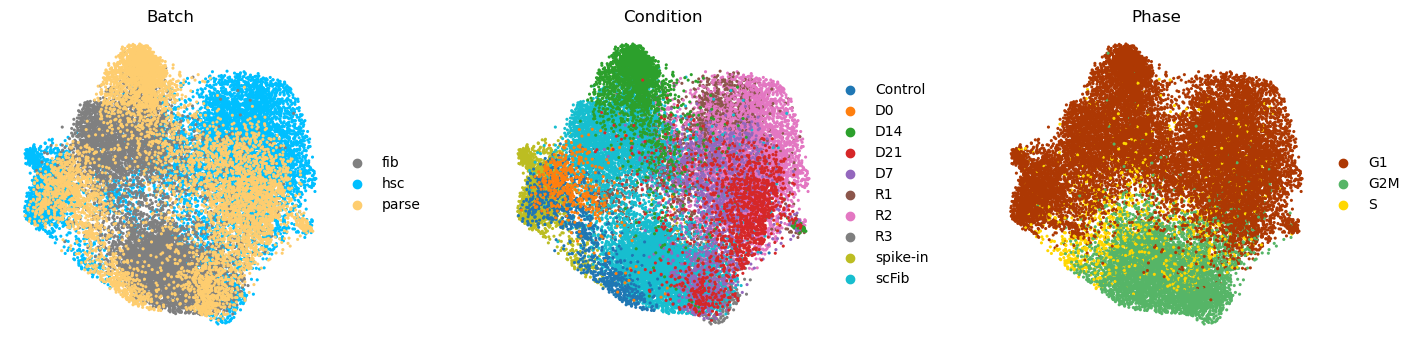

X_scANVI_batch_only:


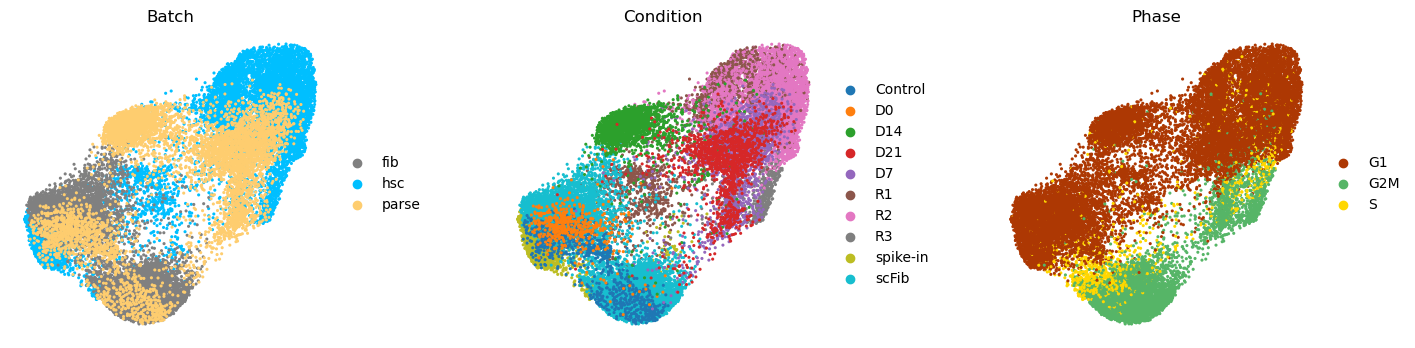

X_scvi_cc_covar:


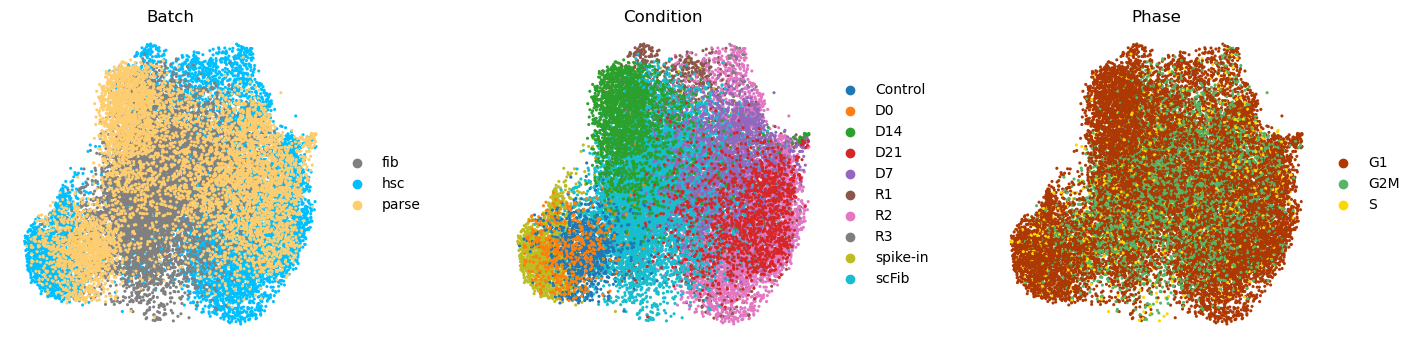

X_scANVI_cc_covar:


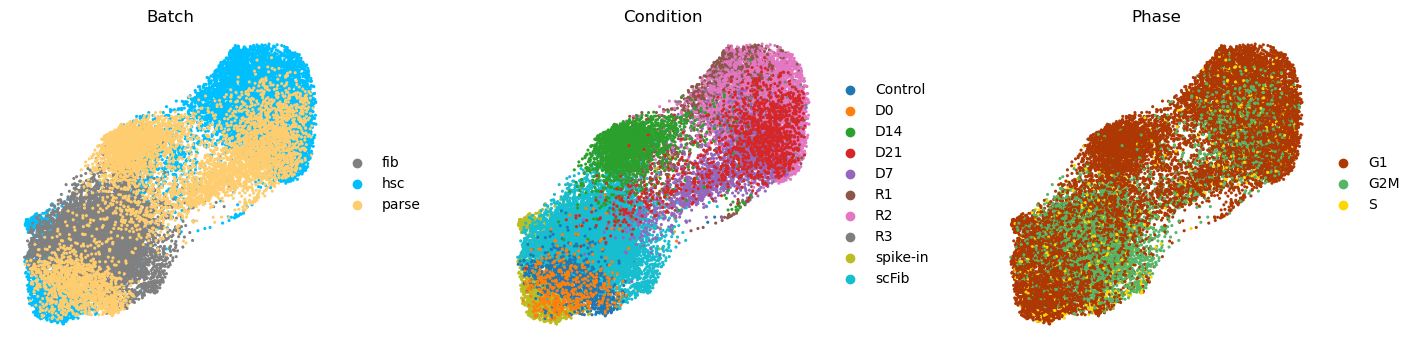

CPU times: user 9.08 s, sys: 2.68 s, total: 11.8 s
Wall time: 14.7 s


In [14]:
%%time
n_neighbors = 35

embedding_keys = [
    "X_pca_unintegrated",
    "X_harmony_batch_only",
    "X_harmony_regress_cc",
    "X_scvi_batch_only",
    "X_scANVI_batch_only",
    "X_scvi_cc_covar",
    "X_scANVI_cc_covar",
]

for rep in embedding_keys:
    
    rsc.get.anndata_to_GPU(adata_eval)
    
    rsc.pp.neighbors(adata_eval, use_rep=rep, n_neighbors=n_neighbors)
    rsc.tl.draw_graph(adata_eval)
    
    rsc.get.anndata_to_CPU(adata_eval)

    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['figure.figsize'] = 4, 4
    
    print(f'{rep}:')
    
    sc.pl.draw_graph(
        adata_eval,
        ncols=3,
        size=20,
        color=['batch', 'group_label', "phase"],
        title=[
            f"Batch",
            f"Condition",
            f"Phase",
        ],
        frameon=False,
        wspace=0.4,
    )

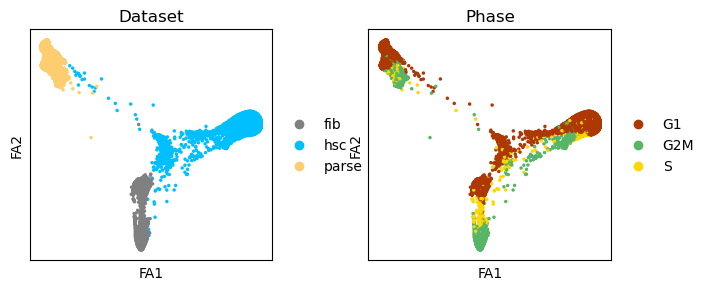

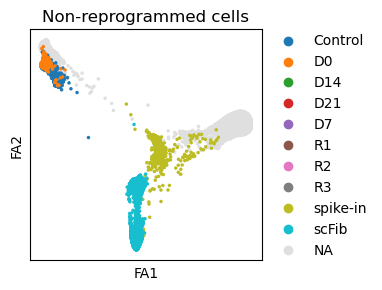

In [16]:
### Unintegrated plots
n_neighbors = 35

rsc.get.anndata_to_GPU(adata_eval)
rsc.pp.neighbors(adata_eval, use_rep='X_pca_unintegrated', n_neighbors=n_neighbors)
rsc.tl.draw_graph(adata_eval)
rsc.get.anndata_to_CPU(adata_eval)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata_eval,
    ncols=2,
    size=25,
    color=['batch', 'phase'],
    title=['Dataset', 'Phase'],
    frameon=True,
    # legend_loc='none',
    na_color='#DFDFDF',
)


mask_obs = adata_eval.obs['group_label'].isin(['Control', 'scFib', 'D0', 'spike-in'])

sc.pl.draw_graph(
    adata_eval,
    ncols=1,
    size=25,
    mask_obs=mask_obs,
    color='group_label',
    title='Non-reprogrammed cells',
    frameon=True,
    # legend_loc='none',
    na_color='#DFDFDF',
)

# Embedding final

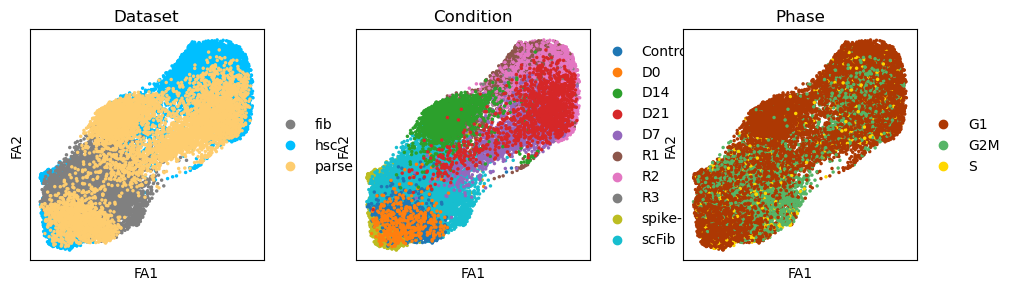

In [17]:
n_neighbors = 35
rep = 'X_scANVI_cc_covar'

rsc.get.anndata_to_GPU(adata_eval)
rsc.pp.neighbors(adata_eval, use_rep=rep, n_neighbors=n_neighbors)
rsc.tl.draw_graph(adata_eval)
rsc.get.anndata_to_CPU(adata_eval)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata_eval,
    ncols=3,
    size=25,
    color=['batch', 'group_label', 'phase'],
    title=['Dataset', 'Condition', 'Phase'],
    frameon=True,
    na_color='#DFDFDF',
)

In [18]:
adata.obs['group_label'] = adata.obs['group_label'].cat.add_categories(['scFib'])

adata.obs.loc[adata.obs['batch'] == 'fib', 'group_label'] = 'scFib'

adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_

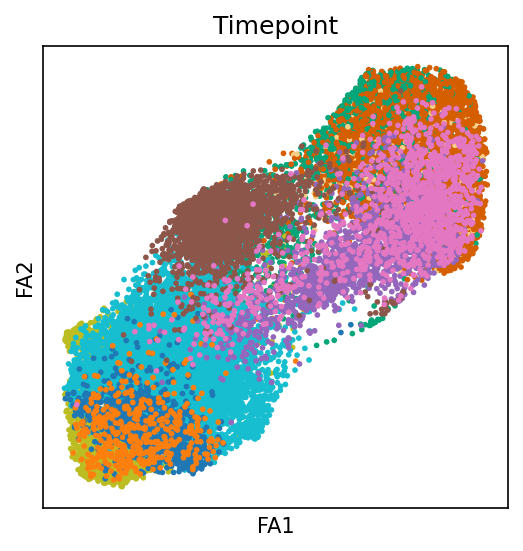

In [19]:
palette = {
    'R1': '#02A679',
    'R2': '#D55E00',
    'R3': '#F9CF86',
    'scFib': '#17BECF',
    'spike-in': '#BCBD22',
    'Control': 'tab:blue',
    'D0': 'tab:orange',
    'D7': 'tab:purple',
    'D14': 'tab:brown',
    'D21': 'tab:pink',
}


plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='group_label',
    palette=palette,
    title='Timepoint',
    frameon=True,
    legend_loc='none',
    na_color='#DFDFDF',
)

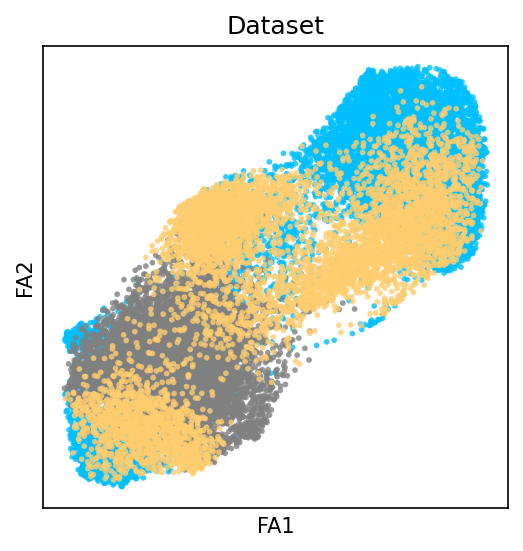

In [20]:
palette = {
    'fib': 'Grey',
    'hsc': 'deepskyblue',
    'parse': '#FECD6F',
}

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='batch',
    palette=palette,
    title='Dataset',
    frameon=True,
    legend_loc='none',
    na_color='#DFDFDF',
    alpha=0.8,
)

In [21]:
from matplotlib.colors import LinearSegmentedColormap

low = '#39312F' # dark
mid = '#5785C1' # blue
high = '#FBA72A' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

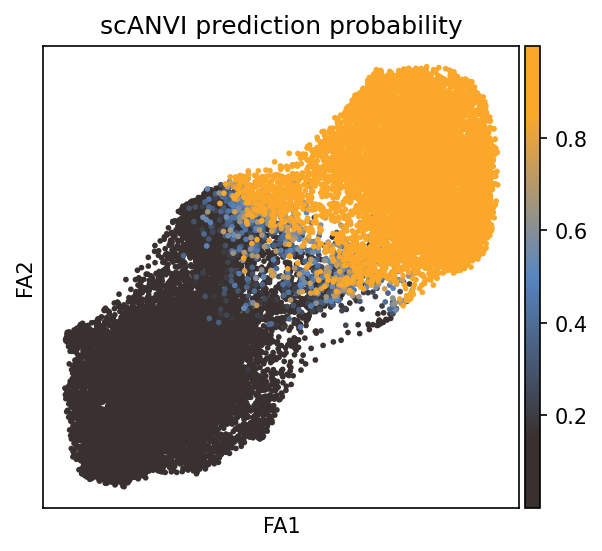

In [23]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4.5, 4

sc.pl.draw_graph(
    adata,
    ncols=1,
    size=30,
    color='prob_D48_like_cc_covar',
    cmap=custom_cmap,
    title='scANVI prediction probability',
    frameon=True,
    # colorbar_loc=None,
    # legend_loc='none',
    # na_color='#DFDFDF',
    # alpha=0.8,
)